In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

monthly = pd.read_csv("../data/monthly_revenue.csv", parse_dates=["Month"]).set_index("Month")["Revenue"]

train = monthly.iloc[:-6]
test = monthly.iloc[-6:]
print("train:", train.index.min().date(), "->", train.index.max().date())
print("test: ", test.index.min().date(), "->", test.index.max().date())

train: 2009-12-01 -> 2011-05-01
test:  2011-06-01 -> 2011-11-01


In [2]:
# Baseline 1: repeat the last value we knew
naive = pd.Series(train.iloc[-1], index=test.index)

# Baseline 2: same month last year
seasonal = pd.Series([monthly[d - pd.DateOffset(years=1)] for d in test.index], index=test.index)

In [3]:
def mae(y, p):  return (y - p).abs().mean()
def mape(y, p): return ((y - p).abs() / y).mean() * 100

results = pd.DataFrame({
    "MAE":    [mae(test, naive), mae(test, seasonal)],
    "MAPE_%": [mape(test, naive), mape(test, seasonal)],
}, index=["Naive (last value)", "Seasonal naive (same month last year)"]).round(1)
results

,MAE,MAPE_%
Naive (last value),237086.4,19.7
Seasonal naive (same month last year),56696.4,6.5


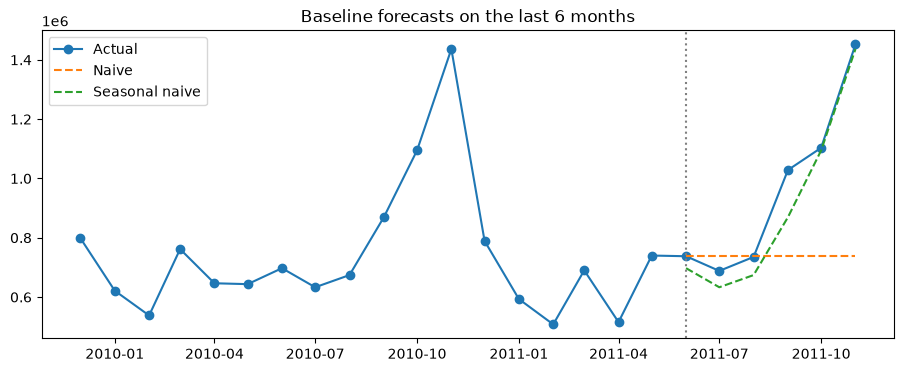

: 

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(monthly.index, monthly, label="Actual", marker="o")
plt.plot(test.index, naive, label="Naive", linestyle="--")
plt.plot(test.index, seasonal, label="Seasonal naive", linestyle="--")
plt.axvline(test.index[0], color="grey", linestyle=":")
plt.legend()
plt.title("Baseline forecasts on the last 6 months")
plt.show()